# PS3

## Problem 1

### (A)

<img src="photos/1a.jpg" width="400" />

### (B)


#### PINN for (A)

In [25]:
# Import TensorFlow and NumPy
import tensorflow as tf
import numpy as np
from pathlib import Path

# Set data type
DTYPE = "float32"
tf.keras.backend.set_floatx(DTYPE)

# Constants: EI = L = w = F = 1 (writeups use P for tip load; code uses F)
L = tf.constant(1.0, dtype=DTYPE)
F = tf.constant(1.0, dtype=DTYPE)  # tip force at x=L, scenario (A)
W = tf.constant(1.0, dtype=DTYPE)  # uniform load intensity w, scenarios (B) and (C)

# PDE: f'''' = Q_load  (set before training: 0 for A, W for B/C with EI=1)
Q_load = tf.Variable(0.0, trainable=False, dtype=DTYPE)


def make_model():
    return tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=(1,)),
            tf.keras.layers.Dense(64, activation="tanh"),
            tf.keras.layers.Dense(64, activation="tanh"),
            tf.keras.layers.Dense(64, activation="tanh"),
            tf.keras.layers.Dense(64, activation="tanh"),
            tf.keras.layers.Dense(1),
        ]
    )


model = make_model()


def f_and_derivs(x):
    """Return f, f', f'', f''', f'''' at x (eager: must stay eager because `model` is replaced each scenario)."""
    x = tf.convert_to_tensor(x)
    with tf.GradientTape(persistent=True) as t4:
        t4.watch(x)
        with tf.GradientTape(persistent=True) as t3:
            t3.watch(x)
            with tf.GradientTape(persistent=True) as t2:
                t2.watch(x)
                with tf.GradientTape() as t1:
                    t1.watch(x)
                    f = model(x)
                f_x = t1.gradient(f, x)
            f_xx = t2.gradient(f_x, x)
        f_xxx = t3.gradient(f_xx, x)
    f_xxxx = t4.gradient(f_xxx, x)
    del t2, t3, t4
    return f, f_x, f_xx, f_xxx, f_xxxx


def residual(x):
    _, _, _, _, f_xxxx = f_and_derivs(x)
    return f_xxxx - Q_load


def mean_square(tensor):
    return tf.reduce_mean(tf.square(tensor))


# Case (A): cantilever, tip load F at x=L (diagram P = F in code), q=0 in domain.
# Part (a) y = F/(6EI)(x^3 - 3Lx^2) gives EI y'''(L) = F at x=L (EI=1).
# If your grader insists on EI v'''(L) = -F from the figure, use shear_free + F instead.
def bc_terms_case_A():
    x_fixed = tf.zeros((1, 1), dtype=DTYPE)
    x_free = tf.ones((1, 1), dtype=DTYPE) * L
    f_fixed, slope_fixed, _, _, _ = f_and_derivs(x_fixed)
    _, _, moment_free, shear_free, _ = f_and_derivs(x_free)
    # Keys must not contain f''' inside "..." — TensorFlow AutoGraph misparses that as an f-string.
    return {
        "disp_0": f_fixed,
        "slope_0": slope_fixed,
        "moment_L": moment_free,
        "shear_L_minus_F": shear_free - F,
    }


# Case (B): cantilever, uniform load — f'''' = w; free end: M=V=0
def bc_terms_case_B():
    x_fixed = tf.zeros((1, 1), dtype=DTYPE)
    x_free = tf.ones((1, 1), dtype=DTYPE) * L
    f_fixed, slope_fixed, _, _, _ = f_and_derivs(x_fixed)
    _, _, moment_free, shear_free, _ = f_and_derivs(x_free)
    return {
        "disp_0": f_fixed,
        "slope_0": slope_fixed,
        "moment_L": moment_free,
        "shear_L": shear_free,
    }


# Case (C): simply supported, uniform load — f=M=0 at both ends
def bc_terms_case_C():
    x0 = tf.zeros((1, 1), dtype=DTYPE)
    xL = tf.ones((1, 1), dtype=DTYPE) * L
    f0, _, m0, _, _ = f_and_derivs(x0)
    fL, _, mL, _, _ = f_and_derivs(xL)
    return {
        "disp_0": f0,
        "disp_L": fL,
        "moment_0": m0,
        "moment_L": mL,
    }


def train_pinn(bc_terms_fn, num_steps=5000, print_every=200, lr=1e-3, N_col=200):
    """Collocation on (0, L); BC residuals from bc_terms_fn."""
    global model
    x_col = np.random.rand(N_col, 1).astype(np.float32) * float(L.numpy())
    x_col = tf.convert_to_tensor(x_col, dtype=DTYPE)
    optimizer = tf.keras.optimizers.Adam(lr)

    @tf.function
    def train_step(xc):
        with tf.GradientTape() as tape:
            r = residual(xc)
            loss_pde = mean_square(r)
            bc = bc_terms_fn()
            loss_bc = tf.constant(0.0, dtype=DTYPE)
            for name in bc:
                loss_bc = loss_bc + mean_square(bc[name])
            loss_total = loss_pde + loss_bc
        grads = tape.gradient(loss_total, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        return loss_total, loss_pde, loss_bc

    for step in range(num_steps):
        loss_total, loss_pde, loss_bc = train_step(x_col)
        if step % print_every == 0:
            print(
                "step:", step,
                "  total:", float(loss_total.numpy()),
                "  pde:", float(loss_pde.numpy()),
                "  bc:", float(loss_bc.numpy()),
            )


def local_homework_dir():
    for p in [Path(".").resolve()] + list(Path(".").resolve().parents):
        if (p / "PS3.ipynb").is_file():
            return p
    return Path(".").resolve()


def f_analytic_A(x):
    """Part (a): y = F/(6EI) (x^3 - 3 L x^2); with EI=L=F=1 this is x^3/6 - x^2/2."""
    x = np.asarray(x, dtype=np.float64)
    Lv, Fv = float(L.numpy()), float(F.numpy())
    return (Fv / 6.0) * (x ** 3 - 3.0 * Lv * x ** 2)


def f_analytic_B(x):
    """Part (a): y = (w x^2)/(24 EI) (6 L^2 - 4 L x + x^2); L=w=EI=1 matches homework red box."""
    x = np.asarray(x, dtype=np.float64)
    Lv, wv = float(L.numpy()), float(W.numpy())
    return (wv / 24.0) * x ** 2 * (6.0 * Lv ** 2 - 4.0 * Lv * x + x ** 2)


def f_analytic_C(x):
    """Part (a): y = -w/(24 EI) (x^4 - 2 L x^3 + L^3 x); L=w=EI=1 matches homework red box."""
    x = np.asarray(x, dtype=np.float64)
    Lv, wv = float(L.numpy()), float(W.numpy())
    return -(wv / 24.0) * (x ** 4 - 2.0 * Lv * x ** 3 + (Lv ** 3) * x)


def plot_pinn_vs_analytic(
    title,
    f_analytic_fn,
    save_name,
    *,
    invert_yaxis=True,
    analytic_eq=None,
):
    import matplotlib.pyplot as plt

    Lv = float(L.numpy())
    x_plot = np.linspace(0.0, Lv, 200).reshape(-1, 1).astype(np.float32)
    x_tf = tf.convert_to_tensor(x_plot, dtype=DTYPE)
    f_pinn = model(x_tf).numpy().ravel()
    f_true = f_analytic_fn(x_plot.ravel())

    charts_dir = local_homework_dir() / "charts"
    charts_dir.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x_plot.ravel(), f_true, "k-", label="Analytic")
    ax.plot(x_plot.ravel(), f_pinn, "r--", label="PINN")
    if invert_yaxis:
        ax.invert_yaxis()
    ax.set_xlabel("x (along beam)")
    ax.set_ylabel("deflection f(x)")
    ax.set_title(title)
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
    if analytic_eq:
        ax.text(
            0.02,
            0.5,
            analytic_eq,
            transform=ax.transAxes,
            fontsize=11,
            verticalalignment="center",
            bbox=dict(boxstyle="round,pad=0.35", facecolor="wheat", alpha=0.9),
        )
    out = charts_dir / save_name
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", out.resolve())



In [26]:
# Scenario (A): cantilever, tip load — f'''' = 0 in domain
Q_load.assign(0.0)
model = make_model()
train_pinn(bc_terms_case_A)


step: 0   total: 1.0104570388793945   pde: 0.004212914500385523   bc: 1.00624418258667
step: 200   total: 0.002242843620479107   pde: 0.0019271031487733126   bc: 0.0003157404134981334
step: 400   total: 3.524060230120085e-05   pde: 3.5220320569351315e-05   bc: 2.0282399759707914e-08
step: 600   total: 3.1799230782780796e-05   pde: 3.178077531629242e-05   bc: 1.845496555574755e-08
step: 800   total: 2.7565707569010556e-05   pde: 2.7496129405335523e-05   bc: 6.957826315101556e-08
step: 1000   total: 8.25724855531007e-05   pde: 5.206191781326197e-05   bc: 3.051056592084933e-05
step: 1200   total: 3.645125252660364e-05   pde: 2.0708179363282397e-05   bc: 1.5743074982310645e-05
step: 1400   total: 1.9033532225876115e-05   pde: 1.8402886780677363e-05   bc: 6.306453315119143e-07
step: 1600   total: 0.0002497081586625427   pde: 2.482491072441917e-05   bc: 0.00022488326067104936
step: 1800   total: 5.0204238505102694e-05   pde: 3.163241854053922e-05   bc: 1.8571819964563474e-05
step: 2000   tot

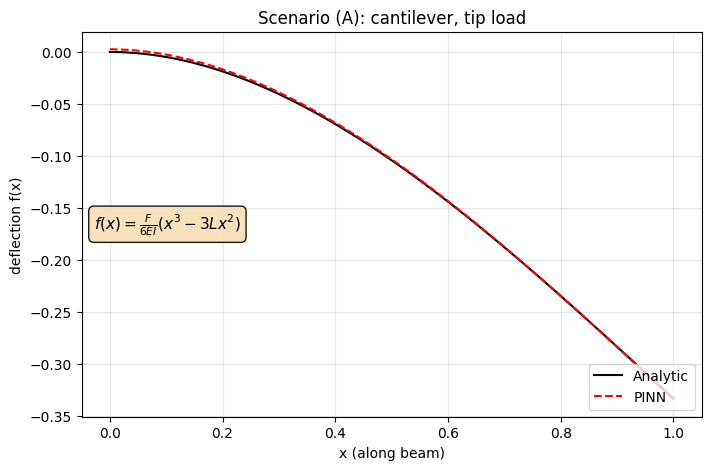

Saved: C:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3\charts\1b_A.png
Boundary condition residuals (A):
  disp_0 = [0.00264832]
  slope_0 = [-0.00350296]
  moment_L = [0.00070152]
  shear_L_minus_F = [0.0004909]


In [27]:
# Scenario (A): PINN vs analytic, save under charts/
plot_pinn_vs_analytic(
    "Scenario (A): cantilever, tip load",
    f_analytic_A,
    "1b_A.png",
    invert_yaxis=False,
    analytic_eq=r"$f(x)=\frac{F}{6EI}\left(x^3-3Lx^2\right)$",
)
bc = bc_terms_case_A()
print("Boundary condition residuals (A):")
for name in bc:
    print(" ", name, "=", bc[name].numpy().reshape(-1))


#### PINN for (B)


In [28]:
# Scenario (B): cantilever, uniform load — f'''' = w (EI=1 → Q_load = W)
Q_load.assign(W)
model = make_model()
train_pinn(bc_terms_case_B)


step: 0   total: 0.9192548394203186   pde: 0.8905531167984009   bc: 0.02870173752307892
step: 200   total: 0.010778025723993778   pde: 0.007890240289270878   bc: 0.0028877852018922567
step: 400   total: 0.003791723633185029   pde: 0.0035913418978452682   bc: 0.00020038180809933692
step: 600   total: 0.0014039934612810612   pde: 0.001376178814098239   bc: 2.7814596251118928e-05
step: 800   total: 0.0002729548723436892   pde: 0.00026216867263428867   bc: 1.0786190614453517e-05
step: 1000   total: 0.002659483114257455   pde: 0.0023300901520997286   bc: 0.00032939304946921766
step: 1200   total: 4.301139779272489e-05   pde: 4.289241405786015e-05   bc: 1.1898204377303045e-07
step: 1400   total: 3.572408968466334e-05   pde: 3.5642387956613675e-05   bc: 8.17003353859036e-08
step: 1600   total: 4.016822640551254e-05   pde: 3.827299224212766e-05   bc: 1.8952338223243714e-06
step: 1800   total: 2.5940960767911747e-05   pde: 2.5909892428899184e-05   bc: 3.1068552175383957e-08
step: 2000   total: 

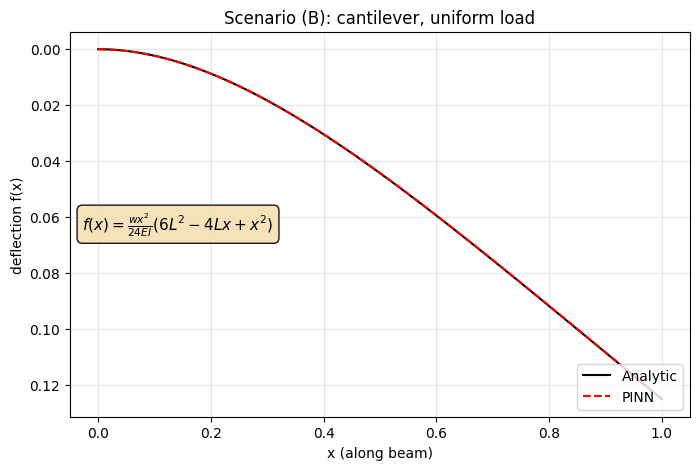

Saved: C:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3\charts\1b_B.png
Boundary condition residuals (B):
  disp_0 = [1.4081597e-06]
  slope_0 = [-1.6719103e-05]
  moment_L = [-6.247498e-05]
  shear_L = [-6.175041e-05]


In [29]:
plot_pinn_vs_analytic(
    "Scenario (B): cantilever, uniform load",
    f_analytic_B,
    "1b_B.png",
    analytic_eq=r"$f(x)=\frac{w x^2}{24EI}\left(6L^2-4Lx+x^2\right)$",
)
bc = bc_terms_case_B()
print("Boundary condition residuals (B):")
for name in bc:
    print(" ", name, "=", bc[name].numpy().reshape(-1))


#### PINN for (C)


In [30]:
# Scenario (C): simply supported, uniform load w (code: W). Part (a) deflection has y'''' = -w/EI with EI=1.
Q_load.assign(-W)
model = make_model()
train_pinn(bc_terms_case_C)


step: 0   total: 0.6595096588134766   pde: 0.3731371760368347   bc: 0.28637248277664185
step: 200   total: 0.007734040729701519   pde: 0.007118606474250555   bc: 0.000615434255450964
step: 400   total: 0.001987302675843239   pde: 0.0016208031447604299   bc: 0.00036649941466748714
step: 600   total: 0.0001814414863474667   pde: 0.00018008153710979968   bc: 1.3599491239801864e-06
step: 800   total: 2.5912826458807103e-05   pde: 2.5840341550065205e-05   bc: 7.248483768762526e-08
step: 1000   total: 0.001269413623958826   pde: 0.0011696802685037255   bc: 9.973331907531247e-05
step: 1200   total: 1.8288548744749278e-05   pde: 1.819831049942877e-05   bc: 9.023765557003571e-08
step: 1400   total: 9.940711606759578e-05   pde: 7.666280725970864e-05   bc: 2.274431062687654e-05
step: 1600   total: 1.5817762687220238e-05   pde: 1.568737206980586e-05   bc: 1.303909726857455e-07
step: 1800   total: 1.0710216884035617e-05   pde: 1.0623239177220967e-05   bc: 8.697791997747117e-08
step: 2000   total: 0

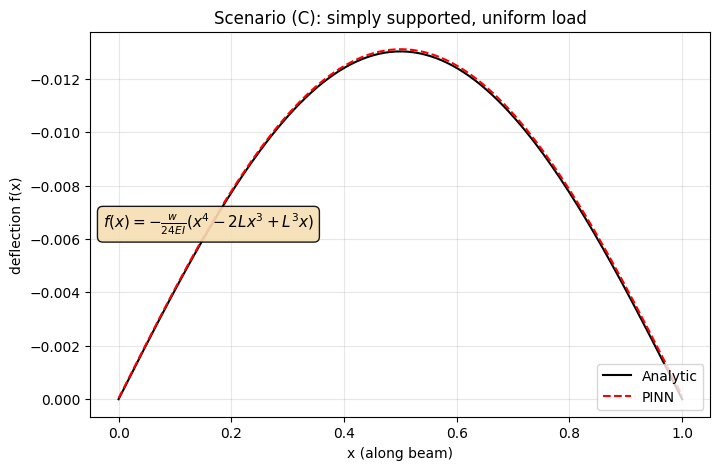

Saved: C:\Users\mpave\OneDrive - Massachusetts Institute of Technology\2.174 Mechanics and Materials via Machine Learning\PS3\charts\1b_C.png
Boundary condition residuals (C):
  disp_0 = [-3.837794e-05]
  disp_L = [-0.00012673]
  moment_0 = [6.5267086e-05]
  moment_L = [6.765872e-05]


In [31]:
plot_pinn_vs_analytic(
    "Scenario (C): simply supported, uniform load",
    f_analytic_C,
    "1b_C.png",
    analytic_eq=r"$f(x)=-\frac{w}{24EI}\left(x^4-2Lx^3+L^3x\right)$",
)
bc = bc_terms_case_C()
print("Boundary condition residuals (C):")
for name in bc:
    print(" ", name, "=", bc[name].numpy().reshape(-1))


### (C)

(i)

<img src="photos/1c.png" width="600" />

(ii)

<img src="photos/1c_ii.png" width="600" />